# Hello world - OpenCV

画像表現形式と基本操作

## 1. 画像の読み込みと表示

画像をソフトウェアで扱う手段として、画像データをPython変数に格納する方法を理解する。

In [1]:
import cv2 as cv
img = cv.imread('data/multi_dot_image1.jpg')  # 読み込み

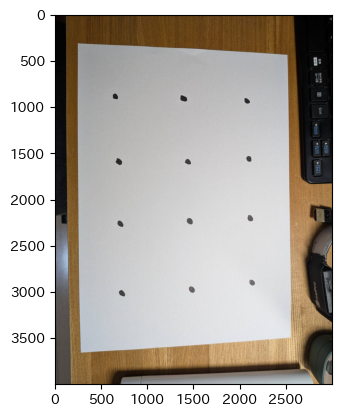

In [2]:
import matplotlib.pyplot as plt
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))  # 表示。BGR -> RGBへ変換
plt.show()

## 2. OpenCV画像データの形式 - HWC (BGR)

画像を操作できるよう、OpenCVの画像データ構造を理解する。

OpenCVの画像データ形式はnumpyのndarray型。

In [3]:
type(img)

numpy.ndarray

OpenCVの画像データはHWC (Height, Width, Channel (Blue, Green, Red))の順番で格納されている。

In [4]:
img.shape  # 画像サイズ H 4000 x W 3000 ピクセル

(4000, 3000, 3)

In [5]:
img

array([[[  6,   8,   9],
        [  6,   8,   9],
        [  6,   8,   9],
        ...,
        [  0,   2,   3],
        [  0,   2,   3],
        [  0,   2,   3]],

       [[  6,   8,   9],
        [  6,   8,   9],
        [  6,   8,   9],
        ...,
        [  0,   2,   3],
        [  0,   2,   3],
        [  0,   2,   3]],

       [[  6,   8,   9],
        [  6,   8,   9],
        [  6,   8,   9],
        ...,
        [  0,   2,   3],
        [  0,   2,   3],
        [  0,   2,   3]],

       ...,

       [[ 69,  72,  77],
        [ 69,  72,  77],
        [ 68,  71,  76],
        ...,
        [121, 135, 153],
        [121, 135, 153],
        [121, 135, 153]],

       [[ 69,  72,  77],
        [ 69,  72,  77],
        [ 68,  71,  76],
        ...,
        [121, 135, 153],
        [121, 135, 153],
        [121, 135, 153]],

       [[ 69,  72,  77],
        [ 69,  72,  77],
        [ 68,  71,  76],
        ...,
        [121, 135, 153],
        [121, 135, 153],
        [121, 135, 153]]

## 3. 画像データとしてのNumPy配列の作成 - np.full

画像データ構造の理解を深めるため、単色画像データを生成する。

In [6]:
import numpy as np

def create_single_color_image(height: int, width:int, color: tuple[int, int, int]) -> np.ndarray:
    """指定された高さ、幅、色の単色画像を作成する関数

    Args:
        height (int): 画像の高さ
        width (int): 画像の幅
        color (tuple[int, int, int]): BGR形式の色 (例: (255, 0, 0)は青)

    Returns:
        np.ndarray: 指定された色の単色画像
    """
    # 指定された色で全てのピクセルを埋める
    image = np.full(shape=(height, width, 3), fill_value=color, dtype=np.uint8)
    return image

numpy.full<br>
https://numpy.org/doc/stable/reference/generated/numpy.full.html

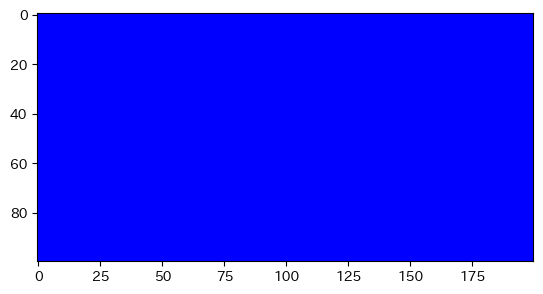

In [7]:
import cv2 as cv
import matplotlib.pyplot as plt
blue_image = create_single_color_image(height=100, width=200, color=(255, 0, 0))
plt.imshow(cv.cvtColor(blue_image, cv.COLOR_BGR2RGB))
plt.show()

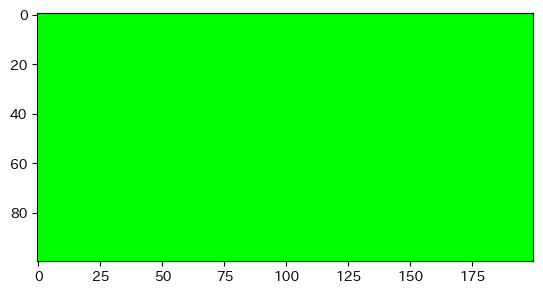

In [8]:
import cv2 as cv
import matplotlib.pyplot as plt
green_image = create_single_color_image(height=100, width=200, color=(0, 255, 0))
plt.imshow(cv.cvtColor(green_image, cv.COLOR_BGR2RGB))
plt.show()

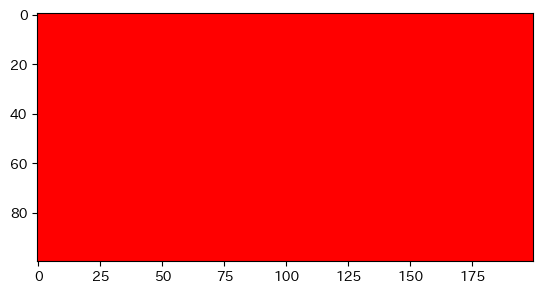

In [9]:
import cv2 as cv
import matplotlib.pyplot as plt
red_image = create_single_color_image(height=100, width=200, color=(0, 0, 255))
plt.imshow(cv.cvtColor(red_image, cv.COLOR_BGR2RGB))
plt.show()

## 4. NumPy配列による画像操作

画像データ構造の理解を深めるため、NumPy配列の状態で画像データを操作する。

### 4.1 画像の結合 (行方向 axis=0) - np.concatenate

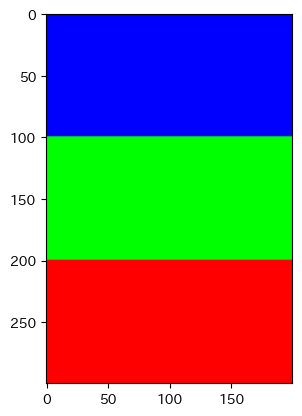

In [10]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

concatenated_image_axis0 = np.concatenate([blue_image, green_image, red_image], axis=0)
plt.imshow(cv.cvtColor(concatenated_image_axis0, cv.COLOR_BGR2RGB))
plt.show()

In [11]:
concatenated_image_axis0.shape

(300, 200, 3)

### 4.2 画像の結合 (列方向 axis=1)

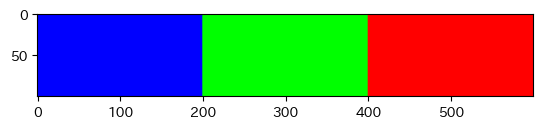

In [12]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

concatenated_image_axis1 = np.concatenate([blue_image, green_image, red_image], axis=1)
plt.imshow(cv.cvtColor(concatenated_image_axis1, cv.COLOR_BGR2RGB))
plt.show()

In [13]:
concatenated_image_axis1.shape

(100, 600, 3)

### 4.3 画像の切り取り (行方向) - slicing

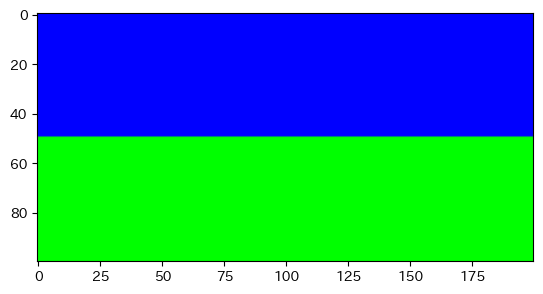

In [14]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

# インデックス50ピクセル目から149ピクセル目までを切り取る (終点は含まない)
cropped_image_0 = concatenated_image_axis0[50:150, :]
plt.imshow(cv.cvtColor(cropped_image_0, cv.COLOR_BGR2RGB))
plt.show()

### 4.4 画像の切り取り (列方向)

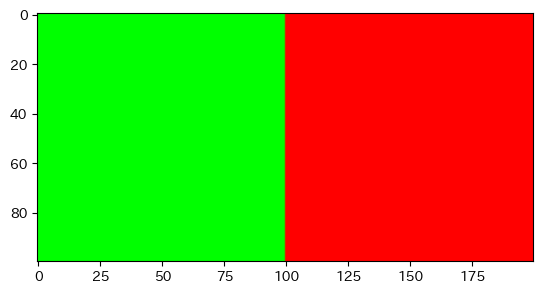

In [15]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

# インデックス300ピクセル目から499ピクセル目までを切り取る (終点は含まない)
cropped_image_1 = concatenated_image_axis1[:, 300:500]
plt.imshow(cv.cvtColor(cropped_image_1, cv.COLOR_BGR2RGB))
plt.show()

### 4.5 NumPyスライス操作の確認

In [16]:
import numpy as np
ary10 = np.arange(10)
print(f"{ary10=}")
print(f"{type(ary10)=}")
print(f"{ary10[:]=}")
print(f"{ary10[0:10]=}")  # インデックス0から9までの10個の要素を切り取る (終点は含まない)
print(f"{ary10[0:5]=}")   # インデックス0から4までの5個の要素を切り取る (終点は含まない)
print(f"{ary10[5:10]=}")  # インデックス5から9までの5個の要素を切り取る (終点は含まない)

ary10=array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
type(ary10)=<class 'numpy.ndarray'>
ary10[:]=array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
ary10[0:10]=array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
ary10[0:5]=array([0, 1, 2, 3, 4])
ary10[5:10]=array([5, 6, 7, 8, 9])


### 4.6 画像の回転 (90度 反時計回り) - np.rot90

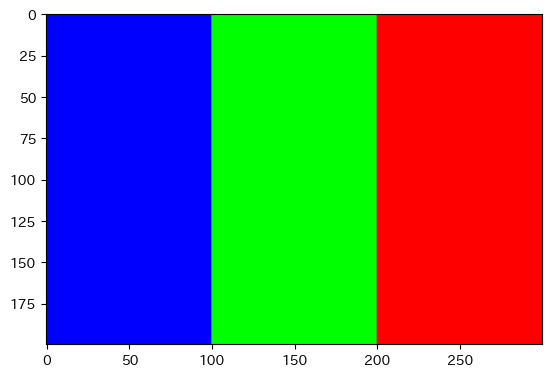

In [17]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

image_rotated_90_ccw = np.rot90(concatenated_image_axis0, k=1)  # 90度反時計回りに回転
plt.imshow(cv.cvtColor(image_rotated_90_ccw, cv.COLOR_BGR2RGB))
plt.show()

In [18]:
print(f"{concatenated_image_axis0.shape=}")
print(f"{image_rotated_90_ccw.shape=}")
print(f"{image_rotated_90_ccw[0, 0]=}")

concatenated_image_axis0.shape=(300, 200, 3)
image_rotated_90_ccw.shape=(200, 300, 3)
image_rotated_90_ccw[0, 0]=array([255,   0,   0], dtype=uint8)


### 4.7 画像の回転 (90度 時計回り)

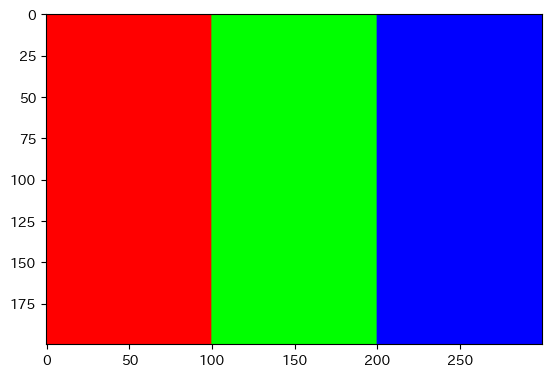

In [19]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

image_rotated_90_cw = np.rot90(concatenated_image_axis0, k=-1)  # 90度時計回りに回転
plt.imshow(cv.cvtColor(image_rotated_90_cw, cv.COLOR_BGR2RGB))
plt.show()

In [20]:
print(f"{concatenated_image_axis0.shape=}")
print(f"{image_rotated_90_cw.shape=}")
print(f"{image_rotated_90_cw[0, 0]=}")

concatenated_image_axis0.shape=(300, 200, 3)
image_rotated_90_cw.shape=(200, 300, 3)
image_rotated_90_cw[0, 0]=array([  0,   0, 255], dtype=uint8)


### 4.8 画像の反転 (行方向 axis=0) - np.flip

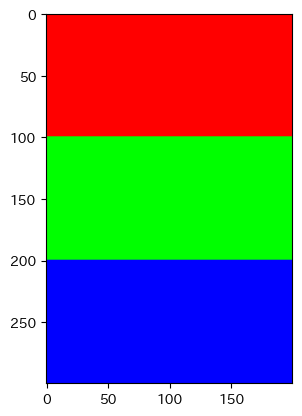

In [21]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

flipped_image_axis0 = np.flip(concatenated_image_axis0, axis=0)  # 行方向に反転
plt.imshow(cv.cvtColor(flipped_image_axis0, cv.COLOR_BGR2RGB))
plt.show()

### 4.9 画像の反転 (列方向 axis=1)

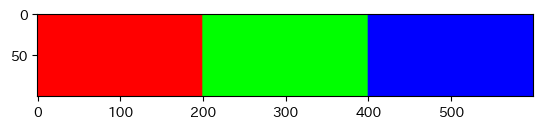

In [22]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

flipped_image_axis1 = np.flip(concatenated_image_axis1, axis=1)  # 列方向に反転
plt.imshow(cv.cvtColor(flipped_image_axis1, cv.COLOR_BGR2RGB))
plt.show()

### 4.10 切り取って貼り付ける

cropped_image_r.shape=(10, 10, 3)


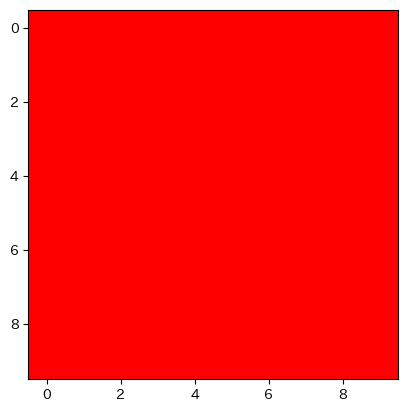

In [23]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

# インデックス10ピクセル目から19ピクセル目までを切り取る (終点は含まない)
cropped_image_r = flipped_image_axis1[10:20, 10:20, :]
print(f"{cropped_image_r.shape=}")
plt.imshow(cv.cvtColor(cropped_image_r, cv.COLOR_BGR2RGB))
plt.show()

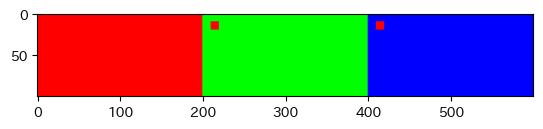

In [24]:
# 切り取った画像を貼り付ける
image_pasted_r = flipped_image_axis1.copy()  # flipped_image_axis1のコピーを作成
image_pasted_r[10:20, 210:220, :] = cropped_image_r
image_pasted_r[10:20, 410:420, :] = cropped_image_r
plt.imshow(cv.cvtColor(image_pasted_r, cv.COLOR_BGR2RGB))
plt.show()

### 4.11 次元の操作 - 1次元配列に変換 - np.ravel

In [25]:
image_blue = image_pasted_r[:, :, 0]  # 青色チャンネルを切り取る
image_blue

array([[  0,   0,   0, ..., 255, 255, 255],
       [  0,   0,   0, ..., 255, 255, 255],
       [  0,   0,   0, ..., 255, 255, 255],
       ...,
       [  0,   0,   0, ..., 255, 255, 255],
       [  0,   0,   0, ..., 255, 255, 255],
       [  0,   0,   0, ..., 255, 255, 255]], shape=(100, 600), dtype=uint8)

In [26]:
image_blue_single_dim = np.ravel(image_blue)  # 1次元配列に変換
image_blue_single_dim

array([  0,   0,   0, ..., 255, 255, 255], shape=(60000,), dtype=uint8)

### 4.12 np.ravel (参照) と np.flatten (コピー)

In [27]:
import numpy as np
c1 = np.array([0, 1, 2, 3, 4, 5])
c2 = c1.reshape(2, 3)  # 2行3列の2次元配列に変換
print(f"{c1=}")
print(f"{c2=}")

c1=array([0, 1, 2, 3, 4, 5])
c2=array([[0, 1, 2],
       [3, 4, 5]])


In [28]:
c3 = c2.ravel()
c4 = c2.flatten()
c3[0] = 6
c4[1] = 7
print(f"{c2=}")
print(f"{c3=}")
print(f"{c4=}")

c2=array([[6, 1, 2],
       [3, 4, 5]])
c3=array([6, 1, 2, 3, 4, 5])
c4=array([0, 7, 2, 3, 4, 5])


TODO:
* HWC - CHW
* openCVのメソッド
